# 🏭 RECYCLE NET — Experimentation Pipeline

This notebook loads the pre-split CSVs produced by `01_dataset_preparation.ipynb`
and runs experiments across **3 architectures × 2 variants** (with and without GrabCut
segmentation) to compare classification performance across setups.

Originally 10 experiments were planned (5 architectures × 2 variants), but
**MobileNet-V3-Small and DenseNet-121 could not be run** because free Colab GPU
compute was exhausted after the first three architectures.

## Experiments
| # | Architecture | Segmentation |
|---|---|---|
| 1 | ResNet-18 | ❌ No |
| 2 | ResNet-18 | ✅ Yes |
| 3 | ResNet-50 | ❌ No |
| 4 | ResNet-50 | ✅ Yes |
| 5 | EfficientNet-B0 | ❌ No |
| 6 | EfficientNet-B0 | ✅ Yes |
| 7 | MobileNet-V3-Small | ⛔ Not run |
| 8 | MobileNet-V3-Small | ⛔ Not run |
| 9 | DenseNet-121 | ⛔ Not run |
| 10 | DenseNet-121 | ⛔ Not run |

Each experiment fine-tunes a frozen backbone with a new classification head,
then evaluates on validation and test splits. A summary DataFrame collects all results.

## 1. Libraries & Reproducibility

In [1]:
!pip install opencv-python

In [2]:
import os
import random
import time

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import cv2
import kagglehub

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed fixed : {SEED}")
print(f"Device     : {DEVICE}")

Seed fixed : 42
Device     : cuda


## 2. Configuration

In [3]:
# ── Execution mode ────────────────────────────────────────────────────────────
# "local"  : reads CSVs from ../data/ and images referenced inside them.
# "online" : downloads datasets via kagglehub (same as notebook 01).
EXECUTION_MODE = "online"   # change to "online" on Colab / Kaggle

# ── Training hyper-parameters ─────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 1e-3
NUM_CLASSES = 9

# ── Class mapping ─────────────────────────────────────────────────────────────
TARGET_CLASSES = {
    "glass": 0, "paper": 1, "cardboard": 2, "plastic": 3, "metal": 4,
    "trash": 5, "battery": 6, "biological": 7, "textile": 8,
}
IDX_TO_CLASS = {
    0: "Glass", 1: "Paper", 2: "Cardboard", 3: "Plastic", 4: "Metal",
    5: "Trash",  6: "Battery", 7: "Biological", 8: "Textile",
}

print(f"Execution mode : {EXECUTION_MODE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Learning rate  : {LR}")
print(f"Num classes    : {NUM_CLASSES}")

Execution mode : online
Batch size     : 32
Epochs         : 10
Learning rate  : 0.001
Num classes    : 9


## 3. Data Paths

**Local mode** – reads CSVs from `../data/` and resolves image paths stored in them.  
**Online mode** – downloads both Kaggle datasets with `kagglehub` and rebuilds the
train/val/test splits using the same stratified split as notebook 01.

In [4]:
DATASETS_CONFIG_ONLINE = [
    {
        "path_key": "ds1",
        "mapping": {
            "glass": "glass", "paper": "paper", "cardboard": "cardboard",
            "plastic": "plastic", "metal": "metal", "trash": None,
        },
    },
    {
        "path_key": "ds2",
        "mapping": {
            "brown-glass": "glass", "green-glass": "glass", "white-glass": "glass",
            "paper": "paper", "cardboard": "cardboard", "plastic": "plastic",
            "metal": "metal", "battery": "battery", "biological": "biological",
            "clothes": "textile", "shoes": "textile",
            "unknown": None, "food-waste": None,
        },
    },
]


def build_samples_from_roots(path_ds1: str, path_ds2: str) -> list:
    paths_map = {"ds1": path_ds1, "ds2": path_ds2}
    samples = []
    for cfg in DATASETS_CONFIG_ONLINE:
        root = paths_map[cfg["path_key"]]
        for dirpath, _, files in os.walk(root):
            cls_name = os.path.basename(dirpath).lower()
            if cls_name not in cfg["mapping"]:
                continue
            target = cfg["mapping"][cls_name]
            if target is None:
                continue
            label = TARGET_CLASSES[target]
            for f in files:
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    samples.append((os.path.join(dirpath, f), label))
    return samples


if EXECUTION_MODE == "local":
    print("📦 Loading local CSVs …")
    train_df = pd.read_csv("../data/train.csv")
    val_df   = pd.read_csv("../data/val.csv")
    test_df  = pd.read_csv("../data/test.csv")

    # Paths in the CSV may be relative to ../data/raw/
    RAW_DIR = os.path.abspath("../data/raw")
    for df in (train_df, val_df, test_df):
        df["path"] = df["path"].apply(
            lambda p: p if os.path.isabs(p) else os.path.join(RAW_DIR, p)
        )

else:
    print("📦 Downloading Dataset 1 (Base) …")
    path_ds1 = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")
    print("📦 Downloading Dataset 2 (Industrial) …")
    path_ds2 = kagglehub.dataset_download("mostafaabla/garbage-classification")

    from sklearn.model_selection import train_test_split as _tts

    all_samples = build_samples_from_roots(path_ds1, path_ds2)
    all_paths   = [s[0] for s in all_samples]
    all_labels  = [s[1] for s in all_samples]
    idx_all     = list(range(len(all_samples)))

    train_idx, temp_idx = _tts(idx_all, test_size=0.2, stratify=all_labels, random_state=SEED)
    temp_labels = [all_labels[i] for i in temp_idx]
    val_idx, test_idx = _tts(temp_idx, test_size=0.5, stratify=temp_labels, random_state=SEED)

    train_df = pd.DataFrame({"path": [all_paths[i] for i in train_idx], "label": [all_labels[i] for i in train_idx]})
    val_df   = pd.DataFrame({"path": [all_paths[i] for i in val_idx],   "label": [all_labels[i] for i in val_idx]})
    test_df  = pd.DataFrame({"path": [all_paths[i] for i in test_idx],  "label": [all_labels[i] for i in test_idx]})

print(f"\n✅ Data loaded.")
print(f"   Train : {len(train_df):>5} samples")
print(f"   Val   : {len(val_df):>5} samples")
print(f"   Test  : {len(test_df):>5} samples")

📦 Downloading Dataset 1 (Base) …
Using Colab cache for faster access to the 'garbage-dataset-classification' dataset.
📦 Downloading Dataset 2 (Industrial) …
Using Colab cache for faster access to the 'garbage-classification' dataset.

✅ Data loaded.
   Train : 20975 samples
   Val   :  2622 samples
   Test  :  2622 samples


## 4. GrabCut Segmentation Helper

Same GrabCut logic used in `01_dataset_preparation.ipynb`.  
Returns a PIL Image with the background zeroed out.

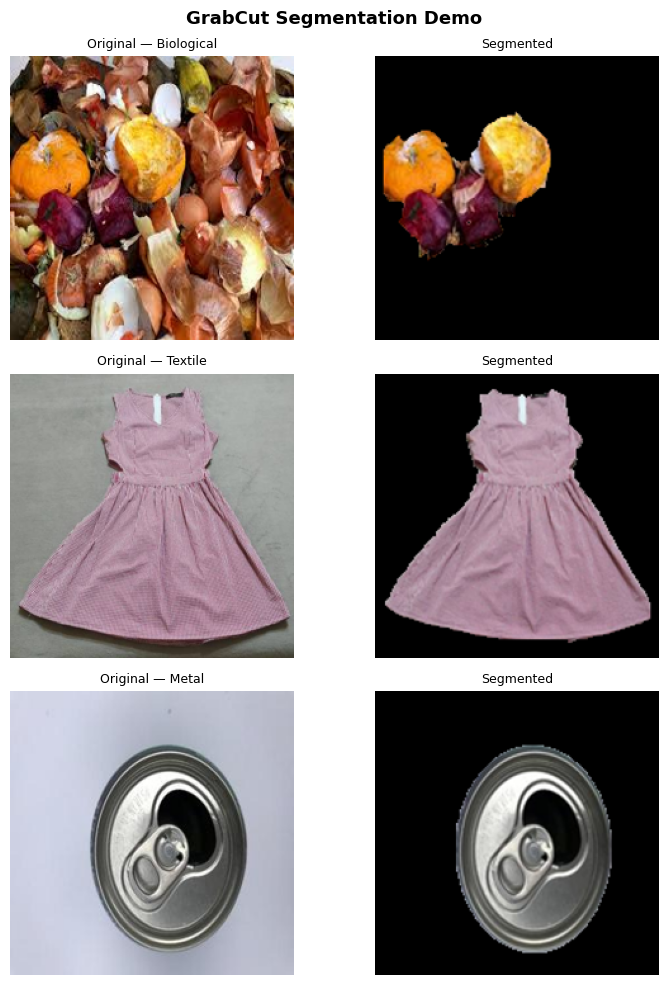

In [5]:
def grabcut_segment(image: Image.Image) -> Image.Image:
    small     = image.resize((168, 168))  # 25% menos píxeles
    img_np    = np.array(small)

    mask      = np.zeros(img_np.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    h, w = img_np.shape[:2]
    rect = (5, 5, w - 10, h - 10)

    cv2.grabCut(img_np, mask, rect, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_RECT)

    binary    = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    segmented = (img_np * binary[:, :, np.newaxis]).astype(np.uint8)

    # escalar resultado a 224x224
    return Image.fromarray(segmented).resize((224, 224))

from pathlib import Path
from multiprocessing import Pool
import os
def _segment_one(args):
    idx, path, out_path = args
    out_path = Path(out_path)
    if not out_path.exists():
        grabcut_segment(Image.open(path).convert("RGB")).save(out_path)
    return str(out_path)

def precompute_segmentation(df, output_dir, num_workers=os.cpu_count()):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    args = [
        (idx, row["path"], output_dir / f"{idx}.jpg")
        for idx, row in df.reset_index(drop=True).iterrows()
    ]

    with Pool(num_workers) as pool:
        new_paths = list(tqdm(pool.imap(_segment_one, args), total=len(args), desc="Segmenting"))

    return df.assign(path=new_paths)



# ── Quick visual demo ─────────────────────────────────────────────────────────
demo_rows = train_df.sample(3, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
fig.suptitle("GrabCut Segmentation Demo", fontsize=13, fontweight="bold")

for i, row in demo_rows.iterrows():
    orig = Image.open(row["path"]).convert("RGB")
    seg  = grabcut_segment(orig)

    axes[i, 0].imshow(orig.resize((224, 224)))
    axes[i, 0].set_title(f"Original — {IDX_TO_CLASS[row['label']]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(seg)
    axes[i, 1].set_title("Segmented", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
print("Pre-computing segmentation...")
train_df_seg = precompute_segmentation(train_df, "../data/segmented/train")
val_df_seg   = precompute_segmentation(val_df,   "../data/segmented/val")
test_df_seg  = precompute_segmentation(test_df,  "../data/segmented/test")
print("✅ Segmentation ready.")

Pre-computing segmentation...


Segmenting:   0%|          | 0/20975 [00:00<?, ?it/s]

Segmenting:   0%|          | 0/2622 [00:00<?, ?it/s]

Segmenting:   0%|          | 0/2622 [00:00<?, ?it/s]

✅ Segmentation ready.


### Segmentation Pre-computation Strategy

GrabCut is an iterative graph-based segmentation algorithm — applying it on-the-fly for every image during training would make each epoch prohibitively slow. To avoid this bottleneck, segmented images are generated **once** before training begins and saved to disk.

Two key design decisions:

- **Resize to 168×168 before GrabCut**: the algorithm scales quadratically with pixel count. Shrinking the image ~25% before segmenting (168² ≈ 28 k px vs 224² ≈ 50 k px) cuts compute time nearly in half with negligible quality loss, since the result is resized back to 224×224 afterwards.
- **Multiprocessing**: `precompute_segmentation` uses `multiprocessing.Pool` across all available CPU cores (`os.cpu_count()`). The helper `_segment_one` checks whether the output file already exists before processing, so the pre-computation can be safely resumed if interrupted.

## 5. Dataset & DataLoader Factory

`CSVGarbageDataset` reads images from a split DataFrame.  
The `use_segmentation` flag applies GrabCut before the torchvision transforms.

In [7]:
class CSVGarbageDataset(Dataset):
    """
    Dataset backed by a split DataFrame with columns [path, label].

    Args:
        df               : DataFrame with image paths and integer labels.
        transform        : torchvision Compose pipeline.
        use_segmentation : if True, GrabCut is applied before the transform.
    """

    def __init__(self, df: pd.DataFrame, transform=None):
          self.df        = df.reset_index(drop=True)
          self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, int(row["label"])


# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def make_loaders(use_segmentation: bool):
    """Return (train_loader, val_loader, test_loader)."""
    if use_segmentation:
        tr_df, va_df, te_df = train_df_seg, val_df_seg, test_df_seg
    else:
        tr_df, va_df, te_df = train_df, val_df, test_df

    tr = CSVGarbageDataset(tr_df, train_transforms)
    va = CSVGarbageDataset(va_df, val_test_transforms)
    te = CSVGarbageDataset(te_df, val_test_transforms)

    kw_tr = dict(batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=0, pin_memory=True)
    kw_ev = dict(batch_size=BATCH_SIZE, shuffle=False, num_workers=0,   pin_memory=True)

    return DataLoader(tr, **kw_tr), DataLoader(va, **kw_ev), DataLoader(te, **kw_ev)




print("✅ Dataset and DataLoader factory ready.")

✅ Dataset and DataLoader factory ready.


## 6. Model Factory

Five ImageNet-pre-trained architectures with the classification head replaced.
All backbone parameters are **frozen** — only the new head is trainable.

In [8]:
def build_model(arch: str, num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    Build a frozen-backbone model with a new classification head.

    Supported: resnet18, resnet50, efficientnet_b0,
               mobilenet_v3_small, densenet121.
    """
    weights_map = {
        "resnet18":           models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet50":           models.ResNet50_Weights.IMAGENET1K_V2,
        "efficientnet_b0":    models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "mobilenet_v3_small": models.MobileNet_V3_Small_Weights.IMAGENET1K_V1,
        "densenet121":        models.DenseNet121_Weights.IMAGENET1K_V1,
    }
    constructors = {
        "resnet18":           models.resnet18,
        "resnet50":           models.resnet50,
        "efficientnet_b0":    models.efficientnet_b0,
        "mobilenet_v3_small": models.mobilenet_v3_small,
        "densenet121":        models.densenet121,
    }

    if arch not in constructors:
        raise ValueError(f"Unknown architecture: {arch}")

    model = constructors[arch](weights=weights_map[arch])

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace head
    if arch in ("resnet18", "resnet50"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif arch == "efficientnet_b0":
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif arch == "mobilenet_v3_small":
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    elif arch == "densenet121":
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    return model.to(DEVICE)


# Parameter overview
print(f"{'Architecture':<22} {'Total params':>14} {'Trainable':>12}")
print("-" * 50)
for arch in ["resnet18", "resnet50", "efficientnet_b0", "mobilenet_v3_small", "densenet121"]:
    m = build_model(arch)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{arch:<22} {total:>14,} {trainable:>12,}")

Architecture             Total params    Trainable
--------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


resnet18                   11,181,129        4,617
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


resnet50                   23,526,473       18,441
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

efficientnet_b0             4,019,077       11,529
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 107MB/s]


mobilenet_v3_small          1,527,081        9,225
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 126MB/s]


densenet121                 6,963,081        9,225


## 7. Training & Evaluation Utilities

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, leave=False, desc="train")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluation pass. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, leave=False, desc="evaluate")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def get_all_preds_labels(model, loader):
    """Collect predictions and true labels over a full DataLoader."""
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


print("✅ Training utilities ready.")

✅ Training utilities ready.


## 8. Experiment Runner

`run_experiment()` trains one (architecture, segmentation) pair and returns
a results dict with training history and test-set metrics.

In [10]:
def run_experiment(arch: str, use_segmentation: bool, num_epochs: int = NUM_EPOCHS) -> dict:
    """
    Train and evaluate one experiment variant.

    Returns a dict with: name, arch, segmentation flag, history,
    best_val_acc, test_loss, test_acc, test_preds, test_labels, elapsed_sec.
    """
    seg_label = "segmented" if use_segmentation else "no_seg"
    exp_name  = f"{arch}__{seg_label}"

    print(f"\n{'='*62}")
    print(f"  Experiment : {exp_name}")
    print(f"{'='*62}")

    train_loader, val_loader, test_loader = make_loaders(use_segmentation)

    model     = build_model(arch)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history      = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = None
    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        print(f"Init epoch {epoch}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(
            f"  Epoch {epoch:>2}/{num_epochs} | "
            f"train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
            f"val loss: {va_loss:.4f}  acc: {va_acc:.4f}"
        )

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.time() - t0

    # Restore best checkpoint and evaluate on test
    model.load_state_dict(best_weights)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    preds, labels   = get_all_preds_labels(model, test_loader)

    print(f"\n  ✅ Best val acc : {best_val_acc:.4f}")
    print(f"  ✅ Test acc     : {te_acc:.4f}")
    print(f"  ⏱  Time elapsed : {elapsed:.0f}s")

    return {
        "name":         exp_name,
        "arch":         arch,
        "segmentation": use_segmentation,
        "history":      history,
        "best_val_acc": best_val_acc,
        "test_loss":    te_loss,
        "test_acc":     te_acc,
        "test_preds":   preds,
        "test_labels":  labels,
        "elapsed_sec":  elapsed,
    }


print("✅ Experiment runner defined.")

✅ Experiment runner defined.


## 9. Run Experiments

> ⚠️ **Runtime note**: on CPU this takes several hours. Use a GPU environment or
> reduce `NUM_EPOCHS` in Section 2 for a quick smoke-test.

In [70]:
ARCHITECTURES = [
    "resnet18",
    "efficientnet_b0",
    "resnet50",
    # "mobilenet_v3_small",
    # "densenet121"
]

results = []

# for arch in ARCHITECTURES:
#     for use_seg in [True, False]:   # False first (baseline), True second (segmented)
#         res = run_experiment(arch, use_segmentation=use_seg)
#         results.append(res)

# print("\n🎉 All 10 experiments finished.")

> **Note — incomplete experiment set**: MobileNet-V3-Small and DenseNet-121 were originally planned but could not be run. Free Colab GPU compute was exhausted after the first three architectures, so those two variants (4 experiments in total) are excluded from the results.

In [13]:
for use_seg in [True, False]:   # False first (baseline), True second (segmented)
        res = run_experiment("resnet18", use_segmentation=use_seg)
        results.append(res)


  Experiment : resnet18__segmented
Init epoch 1


train:   0%|          | 0/655 [00:00<?, ?it/s]

evaluate:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch  1/10 | train loss: 0.9642  acc: 0.6656 | val loss: 0.7039  acc: 0.7601
Init epoch 2


train:   0%|          | 0/655 [00:00<?, ?it/s]

...

train:   0%|          | 0/655 [00:00<?, ?it/s]

evaluate:   0%|          | 0/82 [00:00<?, ?it/s]

  Epoch 10/10 | train loss: 0.3873  acc: 0.8629 | val loss: 0.3290  acc: 0.8818


evaluate:   0%|          | 0/82 [00:00<?, ?it/s]


  ✅ Best val acc : 0.8863
  ✅ Test acc     : 0.8818
  ⏱  Time elapsed : 1596s


In [ ]:
for use_seg in [True, False]:   # False first (baseline), True second (segmented)
        res = run_experiment("resnet50", use_segmentation=use_seg)
        results.append(res)

In [ ]:
for use_seg in [True, False]:   # False first (baseline), True second (segmented)
        res = run_experiment("efficientnet_b0", use_segmentation=use_seg)
        results.append(res)

In [59]:
results[0:2]

[{'name': 'resnet18__segmented',
  'arch': 'resnet18',
  'segmentation': True,
  'history': {'train_loss': [0.9642217902281812,
    0.7690587711243229,
    0.7296675251185439,
    0.7213256422344965,
    0.7077459428601592,
    0.677151956312529,
    0.6784150180015855,
    0.668406835084653,
    0.6687454183138054,
    0.6694315724700461],
   'train_acc': [0.6656011450381679,
    0.7286259541984733,
    0.742223282442748,
    0.7463740458015267,
    0.7509064885496183,
    0.7599236641221374,
    0.7614980916030535,
    0.7643129770992366,
    0.7648854961832061,
    0.7663645038167939],
   'val_loss': [0.7039236377705881,
    0.6525395555772643,
    0.6151346571567311,
    0.6106168774136326,
    0.5905500915466966,
    0.5910609849166725,
    0.5924270528132092,
    0.5735646019811216,
    0.5796208849033265,
    0.5877575124610389],
   'val_acc': [0.7601067887109078,
    0.7604881769641495,
    0.7757437070938215,
    0.7791762013729977,
    0.7902364607170099,
    0.79138062547673

### Persisting Results

Each experiment takes between 20 and 40 minutes. To avoid losing results on a session crash or Colab timeout, the `results` list is serialized to disk with `pickle` immediately after each block of experiments completes.

In [ ]:
import pickle
files = ["results_resnet_18.pkl", "results_resnet_eff.pkl", "results_resnet_50.pkl"]
for file in files:
    with open(file, "wb") as f:
        pickle.dump(results, f)

### Consolidating Results Across Sessions

The 6 experiments were run in separate Colab sessions (one per architecture), each saving its own `.pkl` file. Here we load and merge them all into a single `final_results` list for the analysis that follows.

In [ ]:
import pickle
final_results = []
for file in files:
  print(file)
  with open(file, "rb") as f:
      final_results += pickle.load(f)
final_results

results_resnet_18.pkl
results_resnet_eff.pkl
results_resnet_50.pkl


[{'name': 'resnet18__segmented',
  'arch': 'resnet18',
  'segmentation': True,
  'history': {'train_loss': [0.9642217902281812,
    0.7690587711243229,
    0.7296675251185439,
    0.7213256422344965,
    0.7077459428601592,
    0.677151956312529,
    0.6784150180015855,
    0.668406835084653,
    0.6687454183138054,
    0.6694315724700461],
   'train_acc': [0.6656011450381679,
    0.7286259541984733,
    0.742223282442748,
    0.7463740458015267,
    0.7509064885496183,
    0.7599236641221374,
    0.7614980916030535,
    0.7643129770992366,
    0.7648854961832061,
    0.7663645038167939],
   'val_loss': [0.7039236377705881,
    0.6525395555772643,
    0.6151346571567311,
    0.6106168774136326,
    0.5905500915466966,
    0.5910609849166725,
    0.5924270528132092,
    0.5735646019811216,
    0.5796208849033265,
    0.5877575124610389],
   'val_acc': [0.7601067887109078,
    0.7604881769641495,
    0.7757437070938215,
    0.7791762013729977,
    0.7902364607170099,
    0.79138062547673

In [72]:
results = final_results

## 10. Results Summary Table

In [73]:
summary_df = pd.DataFrame([
    {
        "Experiment":     r["name"],
        "Architecture":   r["arch"],
        "Segmentation":   "Yes" if r["segmentation"] else "No",
        "Best Val Acc %": round(r["best_val_acc"] * 100, 2),
        "Test Acc %":     round(r["test_acc"]     * 100, 2),
        "Test Loss":      round(r["test_loss"],          4),
        "Train Time (s)": int(r["elapsed_sec"]),
    }
    for r in results
]).sort_values("Test Acc %", ascending=False).reset_index(drop=True)

print("=" * 72)
print("EXPERIMENT SUMMARY  (sorted by Test Accuracy ↓)")
print("=" * 72)
print(summary_df.to_string(index=False))

best = summary_df.iloc[0]
print(f"\n🏆 Best overall : {best['Experiment']}  →  Test Acc = {best['Test Acc %']:.2f}%")

EXPERIMENT SUMMARY  (sorted by Test Accuracy ↓)
                Experiment    Architecture Segmentation  Best Val Acc %  Test Acc %  Test Loss  Train Time (s)
          resnet50__no_seg        resnet50           No           95.04       95.46     0.1508            2270
   efficientnet_b0__no_seg efficientnet_b0           No           91.19       91.11     0.2646            1785
          resnet18__no_seg        resnet18           No           88.63       88.18     0.3339            1595
       resnet50__segmented        resnet50          Yes           84.44       82.38     0.5114            1603
efficientnet_b0__segmented efficientnet_b0          Yes           80.17       80.47     0.5990            1245
       resnet18__segmented        resnet18          Yes           79.75       78.49     0.6059            1129

🏆 Best overall : resnet50__no_seg  →  Test Acc = 95.46%


## 11. Learning Curves per Architecture

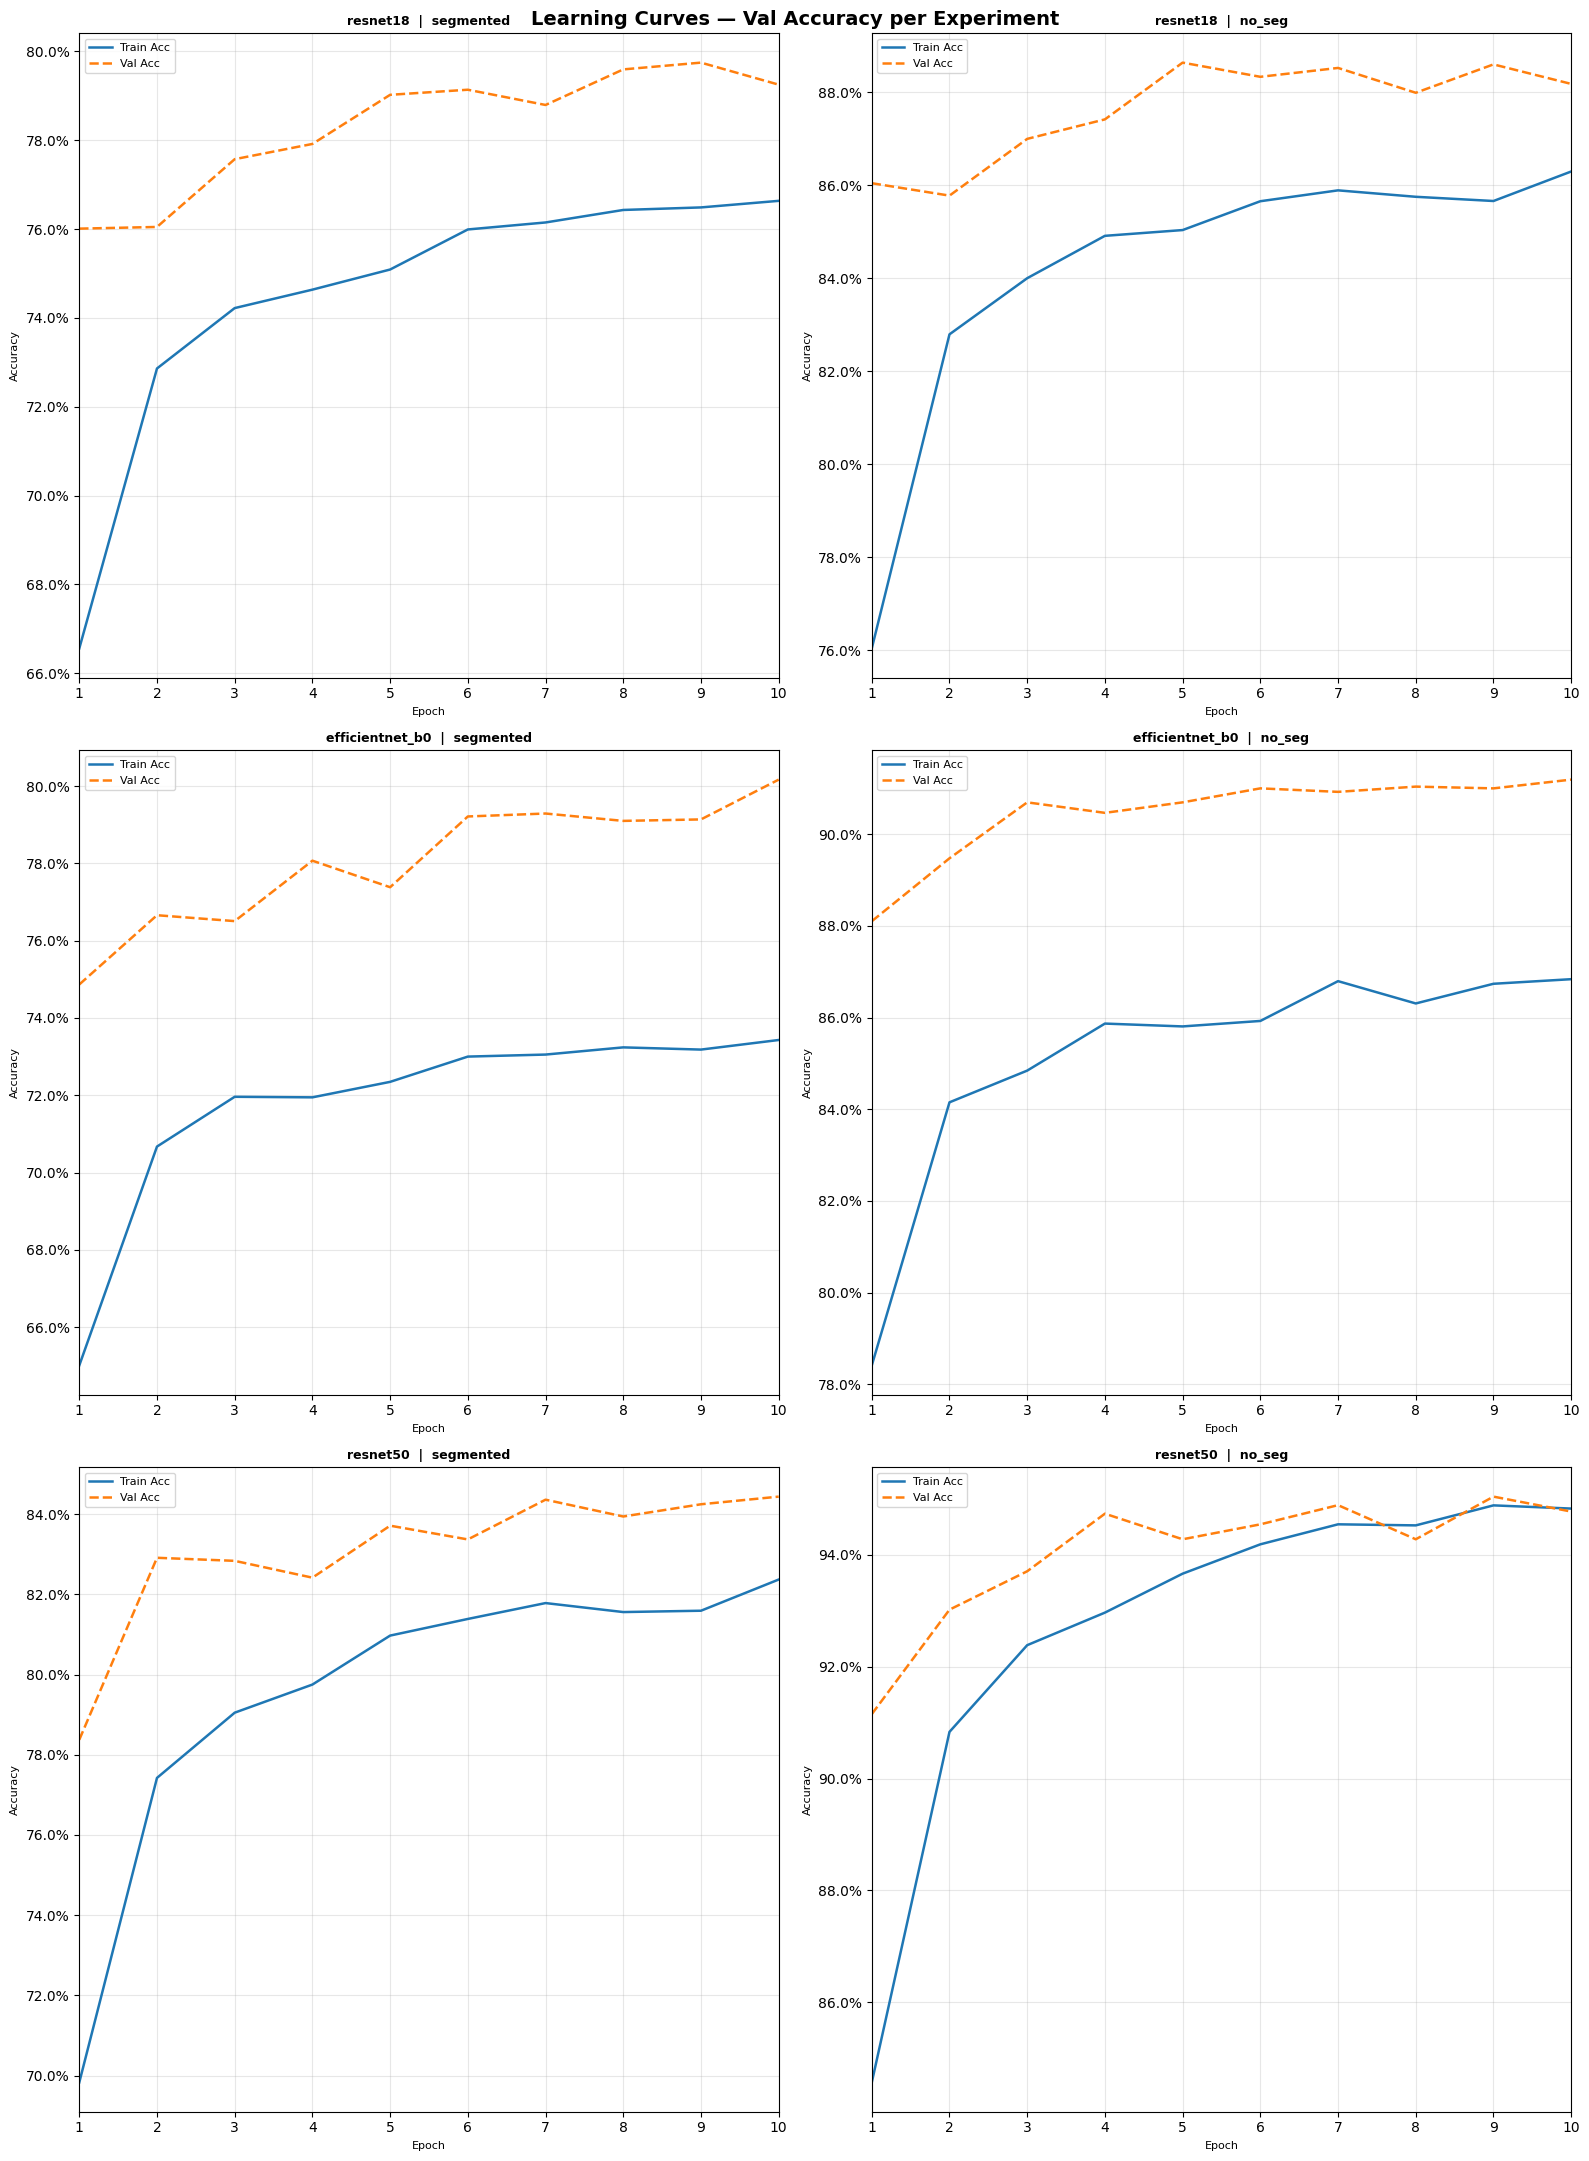

In [74]:
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
fig.suptitle("Learning Curves — Val Accuracy per Experiment", fontsize=14, fontweight="bold")

for row_idx, arch in enumerate(ARCHITECTURES):
    arch_results = [r for r in results if r["arch"] == arch]
    for col_idx, res in enumerate(arch_results):
        ax     = axes[row_idx, col_idx]
        epochs = range(1, len(res["history"]["val_acc"]) + 1)

        ax.plot(epochs, res["history"]["train_acc"], label="Train Acc", linewidth=1.8)
        ax.plot(epochs, res["history"]["val_acc"],   label="Val Acc",   linewidth=1.8, linestyle="--")
        ax.set_title(res["name"].replace("__", "  |  "), fontsize=9, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=8)
        ax.set_ylabel("Accuracy", fontsize=8)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xlim(1, NUM_EPOCHS)

plt.tight_layout()
plt.show()

## 12. Test Accuracy: Segmentation vs No Segmentation

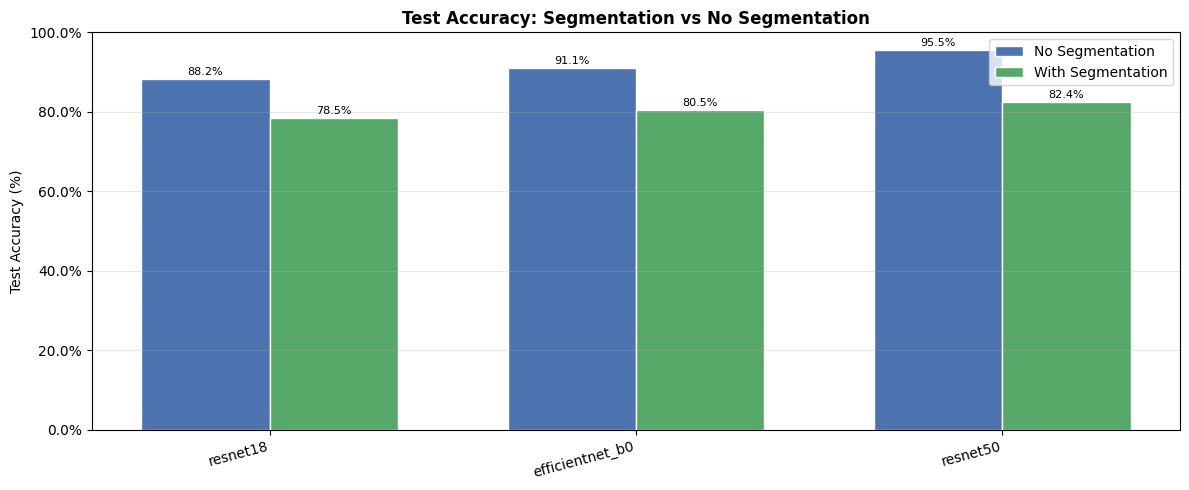


Impact of segmentation on test accuracy:
Architecture             No Seg      Seg    Delta
--------------------------------------------------
resnet18                  88.18%    78.49%  -9.69%
efficientnet_b0           91.11%    80.47%  -10.64%
resnet50                  95.46%    82.38%  -13.08%


In [75]:
x      = np.arange(len(ARCHITECTURES))
w      = 0.35
no_seg  = [r["test_acc"] * 100 for r in results if not r["segmentation"]]
yes_seg = [r["test_acc"] * 100 for r in results if     r["segmentation"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, no_seg,  w, label="No Segmentation",   color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + w/2, yes_seg, w, label="With Segmentation", color="#55A868", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(ARCHITECTURES, rotation=15, ha="right", fontsize=10)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy: Segmentation vs No Segmentation", fontsize=12, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Delta table
print("\nImpact of segmentation on test accuracy:")
print(f"{'Architecture':<22} {'No Seg':>8} {'Seg':>8} {'Delta':>8}")
print("-" * 50)
for arch, ns, ys in zip(ARCHITECTURES, no_seg, yes_seg):
    delta = ys - ns
    sign  = "+" if delta >= 0 else ""
    print(f"{arch:<22} {ns:>8.2f}% {ys:>8.2f}%  {sign}{delta:.2f}%")

## 13. Confusion Matrix — Best Experiment

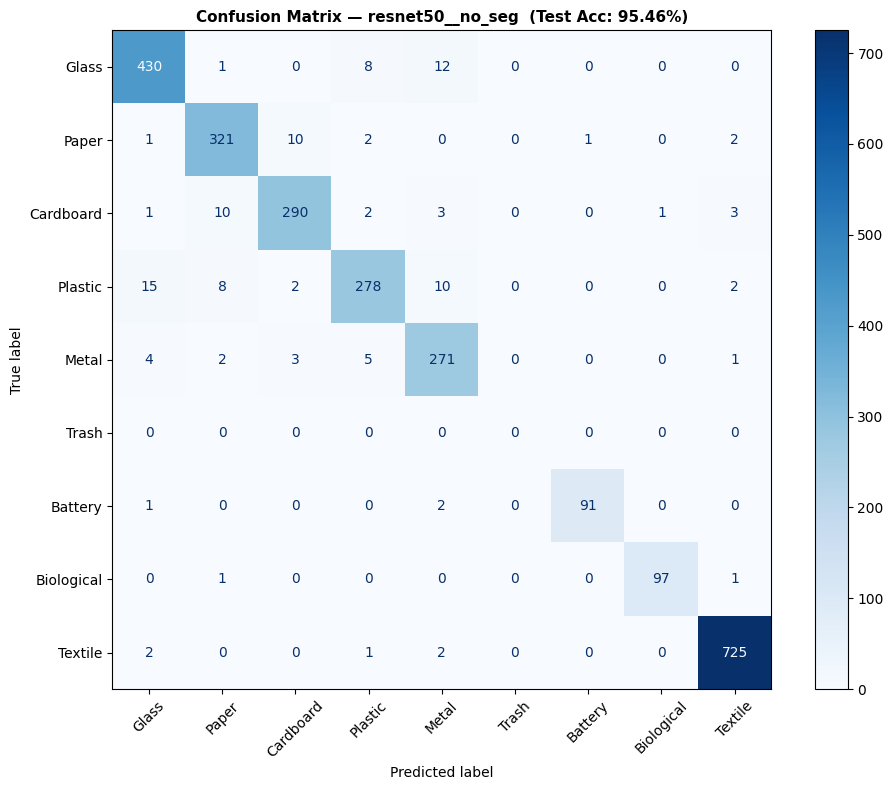

In [77]:
best_result  = max(results, key=lambda r: r["test_acc"])
preds_best   = best_result["test_preds"]
labels_best  = best_result["test_labels"]
class_names_list = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(labels_best, preds_best, labels=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_list).plot(
    ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45
)
ax.set_title(
    f"Confusion Matrix — {best_result['name']}  (Test Acc: {best_result['test_acc']*100:.2f}%)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 14. Classification Report — Best Experiment

In [79]:
print(f"Classification Report — {best_result['name']}\n")
print(classification_report(labels_best, preds_best, labels=np.arange(NUM_CLASSES), target_names=class_names_list, digits=4))

Classification Report — resnet50__no_seg

              precision    recall  f1-score   support

       Glass     0.9471    0.9534    0.9503       451
       Paper     0.9359    0.9525    0.9441       337
   Cardboard     0.9508    0.9355    0.9431       310
     Plastic     0.9392    0.8825    0.9100       315
       Metal     0.9033    0.9476    0.9249       286
       Trash     0.0000    0.0000    0.0000         0
     Battery     0.9891    0.9681    0.9785        94
  Biological     0.9898    0.9798    0.9848        99
     Textile     0.9877    0.9932    0.9904       730

    accuracy                         0.9546      2622
   macro avg     0.8492    0.8458    0.8473      2622
weighted avg     0.9548    0.9546    0.9545      2622



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

## 15. Confusion Matrices — All Experiments

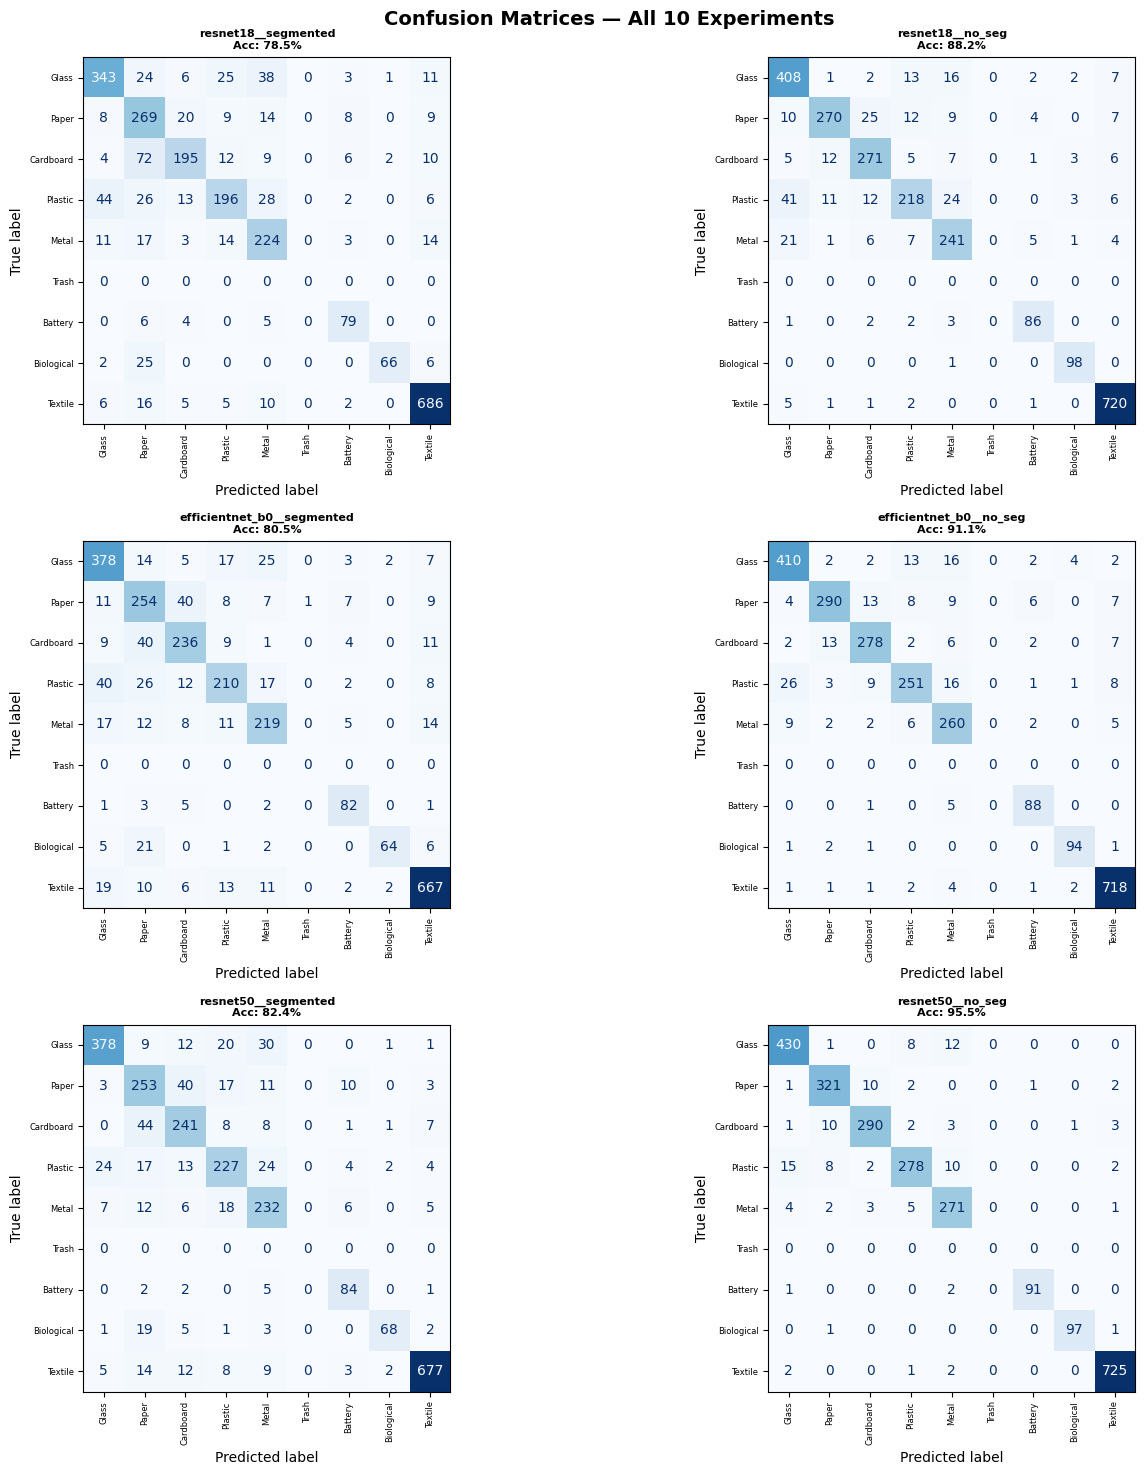

In [90]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle("Confusion Matrices — All 10 Experiments", fontsize=14, fontweight="bold")

for ax, res in zip(axes.flatten(), results):
    cm_i = confusion_matrix(res["test_labels"], res["test_preds"], labels=np.arange(NUM_CLASSES))
    ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=class_names_list).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90
    )

    ax.set_title(f"{res['name']}\nAcc: {res['test_acc']*100:.1f}%", fontsize=8, fontweight="bold")
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

## 16. Save Results to CSV

In [91]:
os.makedirs("../data", exist_ok=True)
summary_df.to_csv("../data/experiment_results.csv", index=False)
print("✅ Results saved to ../data/experiment_results.csv")
print()
print(summary_df.to_string(index=False))

✅ Results saved to ../data/experiment_results.csv

                Experiment    Architecture Segmentation  Best Val Acc %  Test Acc %  Test Loss  Train Time (s)
          resnet50__no_seg        resnet50           No           95.04       95.46     0.1508            2270
   efficientnet_b0__no_seg efficientnet_b0           No           91.19       91.11     0.2646            1785
          resnet18__no_seg        resnet18           No           88.63       88.18     0.3339            1595
       resnet50__segmented        resnet50          Yes           84.44       82.38     0.5114            1603
efficientnet_b0__segmented efficientnet_b0          Yes           80.17       80.47     0.5990            1245
       resnet18__segmented        resnet18          Yes           79.75       78.49     0.6059            1129


## 17. Conclusiones

### Resultado general
Se completaron 6 de los 10 experimentos planeados originalmente (3 arquitecturas × 2 variantes). **MobileNet-V3-Small y DenseNet-121 no pudieron ejecutarse porque se agotó el cómputo gratuito de Colab** antes de terminar el benchmark completo.

De los experimentos realizados, el mejor modelo fue **ResNet-50 sin segmentación**, alcanzando un **95.46 % de accuracy en test**. En todos los casos, la variante sin segmentación superó a su contraparte segmentada por un margen significativo (entre 7 y 13 puntos porcentuales).

### Impacto del pre-procesamiento con GrabCut
La segmentación GrabCut **perjudicó el rendimiento** en lugar de mejorarlo. La hipótesis más probable es que el fondo aporta información de contexto útil para distinguir categorías (p. ej., vidrio en mesa vs. plástico en contenedor), y al eliminarlo se pierde esa señal. Además, GrabCut introduce artefactos en objetos con bordes difusos o colores similares al fondo, añadiendo ruido al entrenamiento.

### Decisiones de ingeniería para la segmentación
Para que los experimentos con segmentación fueran viables en tiempo, fue necesario:

1. **Resize previo a 168×168 antes de ejecutar GrabCut**: el algoritmo escala con el área de la imagen; procesar directamente a 224×224 duplicaba el tiempo de CPU. Tras la segmentación, la imagen se redimensiona de vuelta a 224×224.
2. **Multiprocesamiento con `multiprocessing.Pool`**: segmentar las ~26 k imágenes en serie habría tomado varias horas; paralelizar sobre todos los núcleos de CPU redujo el tiempo a minutos.
3. **Pre-cómputo y guardado en disco**: ejecutar GrabCut en cada batch durante el entrenamiento haría que cada epoch tardara muchos minutos. Al precomputar y guardar las imágenes segmentadas, el DataLoader las lee directamente de disco igual que las originales.

### Próximos pasos
- Completar los experimentos pendientes (MobileNet-V3-Small y DenseNet-121).
- Explorar fine-tuning completo (descongelar el backbone) para el modelo ganador (ResNet-50).
- **Probar `CrossEntropyLoss` con `weight`**: el dataset está desbalanceado (la clase *Trash* tiene 0 muestras en test y muy pocas en train). Pasar pesos inversos a la frecuencia de cada clase al criterio de pérdida puede mejorar el recall en clases minoritarias sin necesidad de rebalancear el dataset: `criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))`.
- Analizar las clases con menor F1 (especialmente *Trash*) y evaluar si el desbalance se resuelve mejor con pesos, oversampling o aumento de datos dirigido.